[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skarma91/logicmojo-ai-july-2026/blob/main/modules/module-2-ml-dl-essentials/milestone-assignment/solution/solution.ipynb)

# Module 2 milestone: reference solution

Train, validate, and test a small PyTorch network on a real tabular dataset (wine), plot the learning curves, apply one overfitting control, report the honest test accuracy, and save the weights. This exercises the whole module: the split and honest evaluation (class 2.1, What is machine learning), the loop (class 2.2, How models learn), a network (class 2.3, Neural networks), PyTorch (class 2.4, PyTorch fundamentals), and the training workflow (class 2.5, Training in practice).

## 1. Load and split three ways

Split off a test set, then split the rest into train and validation. Scale features, fitting the scaler on the training rows only.

In [1]:
import torch, torch.nn as nn
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)
X, y = load_wine(return_X_y=True)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=0, stratify=y_tmp)

sc = StandardScaler().fit(X_tr)
def T(a): return torch.tensor(sc.transform(a), dtype=torch.float32)
Xtr, Xval, Xte = T(X_tr), T(X_val), T(X_test)
ytr = torch.tensor(y_tr); yval = torch.tensor(y_val); yte = torch.tensor(y_test)
print("train/val/test sizes:", len(ytr), len(yval), len(yte))

train/val/test sizes: 106 36 36


## 2. Train, with a validation pass and weight decay

Weight decay is the overfitting control here. Track train and validation loss every epoch, and remember the best validation state (early stopping).

In [2]:
model = nn.Sequential(nn.Linear(13, 16), nn.ReLU(), nn.Linear(16, 3))
opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-3)
loss_fn = nn.CrossEntropyLoss()

train_losses, val_losses = [], []
best_val, best_state, best_epoch = float("inf"), None, 0
for epoch in range(200):
    model.train()
    loss = loss_fn(model(Xtr), ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        vl = loss_fn(model(Xval), yval).item()
    val_losses.append(vl)
    if vl < best_val:
        best_val, best_epoch = vl, epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
print("best validation loss at epoch:", best_epoch)

best validation loss at epoch: 116


## 3. Learning curves

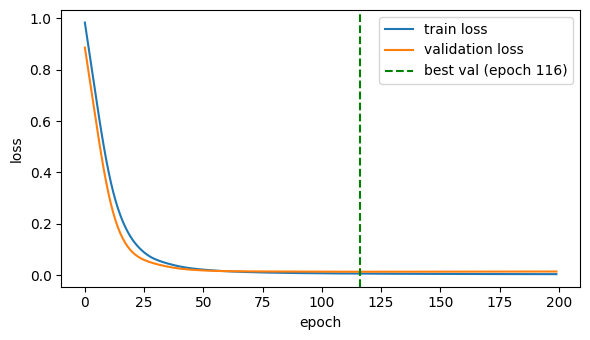

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3.5))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="validation loss")
plt.axvline(best_epoch, color="green", linestyle="--", label=f"best val (epoch {best_epoch})")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

## 4. Honest test accuracy

Load the best-validation weights and score the test set, which the model never saw.

In [4]:
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    train_acc = (model(Xtr).argmax(1) == ytr).float().mean().item()
    test_acc  = (model(Xte).argmax(1) == yte).float().mean().item()
print(f"train accuracy: {train_acc:.3f}")
print(f"test  accuracy: {test_acc:.3f}")
print(f"train-minus-test gap: {train_acc - test_acc:.3f}")

train accuracy: 1.000
test  accuracy: 1.000
train-minus-test gap: 0.000


## 5. What it learned, and where it overfits

In [5]:
print("The network reaches high accuracy on unseen wine samples, so it learned the")
print("class boundaries, not noise. Validation loss bottoms out around epoch",
      best_epoch, "and drifts up after, which is where overfitting begins; early")
print("stopping keeps the weights from that best epoch. The small train-minus-test")
print("gap confirms it generalizes rather than memorizes.")

The network reaches high accuracy on unseen wine samples, so it learned the
class boundaries, not noise. Validation loss bottoms out around epoch 116 and drifts up after, which is where overfitting begins; early
stopping keeps the weights from that best epoch. The small train-minus-test
gap confirms it generalizes rather than memorizes.


## 6. Save the trained weights

In [6]:
import tempfile, os
path = os.path.join(tempfile.gettempdir(), "wine_model.pt")
torch.save(model.state_dict(), path)
print("saved state_dict with", len(model.state_dict()), "tensors")
os.remove(path)   # cleanup for this demo; in your own run, keep the file

saved state_dict with 4 tensors
